In [5]:
import os
ROOT_DIR = "C:\\Adrianov\\Projects\\Project-Satanael\\"
DEMO_DIR = os.path.join(ROOT_DIR, 'attack_demo')
MODEL_DIR = os.path.join(ROOT_DIR, 'models')
APRICOT_TEST_DIR = os.path.join(ROOT_DIR, 'data', 'APRICOTv1.0', 'Images', 'Test')

In [39]:
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
import time
import cv2
import torch

impath = os.path.join(DEMO_DIR, 'smaller(2).png')
image = cv2.imread(impath)

sam = sam_model_registry["vit_b"](checkpoint=os.path.join(MODEL_DIR, 'sam_vit_b_01ec64.pth'))
sam.to(device="cuda" if torch.cuda.is_available() else "cpu")
mask_generator = SamAutomaticMaskGenerator(sam, crop_n_layers=0, min_mask_region_area=200)
start = time.time()
masks = mask_generator.generate(image)
end = time.time()
print(end-start)

175.5696210861206


In [45]:
def show_anns(anns, kernel_size=10):
    if len(anns) == 0:
        return

    sorted_anns = sorted(anns, key=lambda x: x['area'], reverse=True)
    h, w = sorted_anns[0]['segmentation'].shape
    img = np.ones((h, w, 4))
    img[:, :, 3] = 0  # fully transparent background

    # Define square kernel
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

    for ann in sorted_anns:
        m = ann['segmentation'].astype(np.uint8) * 255  # convert to 0-255 uint8 mask
        closed_mask = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel)
        closed_mask = closed_mask.astype(bool)  # back to boolean mask

        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[closed_mask] = color_mask

    plt.imshow(img)

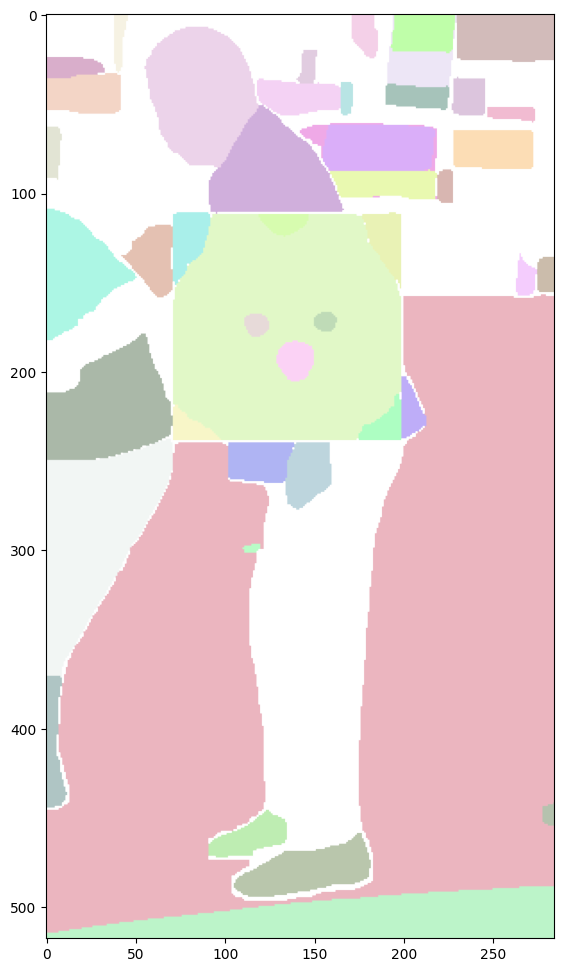

In [46]:
plt.figure(figsize=(12,12))
# plt.imshow(image)
show_anns(masks)
# plt.axis('off')
plt.show() 

In [47]:
def seg_img(impath):
    image = cv2.imread(impath)
    
    sam = sam_model_registry["vit_b"](checkpoint=os.path.join(MODEL_DIR, 'sam_vit_b_01ec64.pth'))
    sam.to(device="cuda" if torch.cuda.is_available() else "cpu")
    mask_generator = SamAutomaticMaskGenerator(sam)
    start = time.time()
    masks = mask_generator.generate(image)
    end = time.time()
    print(end-start)
    return masks

In [48]:
impath = os.path.join(DEMO_DIR, '1497507290696(7).png')
masks = seg_img(impath)


211.33050966262817


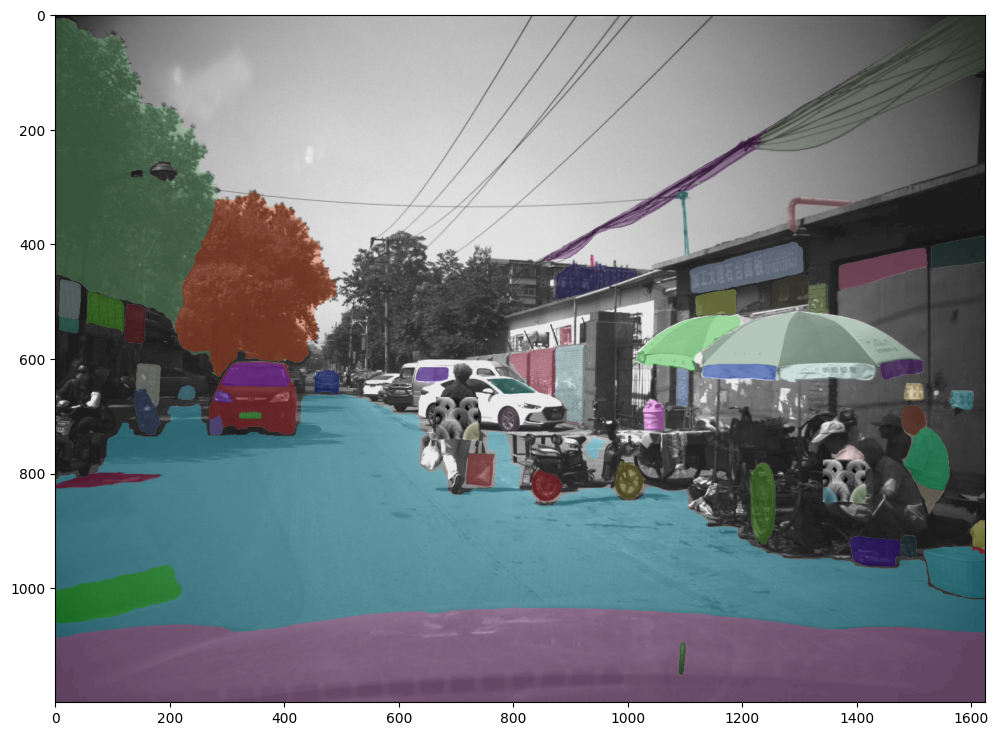

In [54]:
image = cv2.imread(impath, cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(12,12))
plt.imshow(image, cmap='grey')
show_anns(masks)
# plt.axis('off')
plt.show() 